In [ ]:
import pandas as pd

df = pd.read_excel("/content/Telco_customer_churn.xlsx")

print(df.shape)
print(df.info())
print(df.head())

(7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Serv

In [ ]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
df['Churn Label'].value_counts(normalize=True)*100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


In [ ]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

df_clean = df.drop(columns=drop_cols)

print(df_clean.shape)
print(df_clean.columns.tolist())

(7043, 20)
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']


In [ ]:
pd.crosstab(df_clean['Contract'],
            df_clean['Churn Label'])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


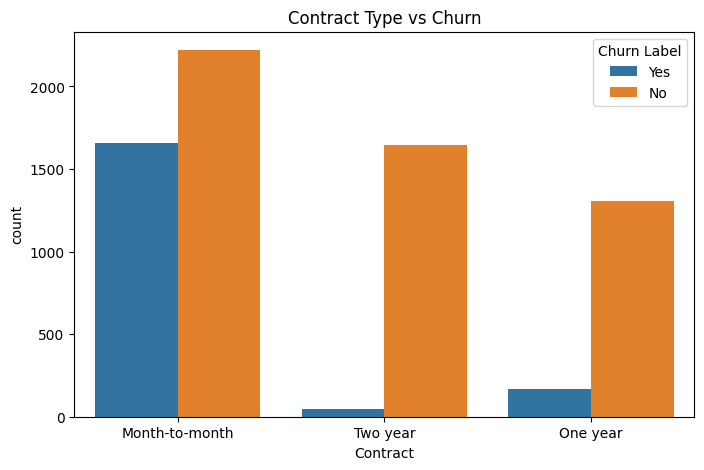

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df_clean
)

plt.title('Contract Type vs Churn')
plt.show()

In [ ]:
pd.crosstab(df_clean['Internet Service'],
            df_clean['Churn Label'])

Churn Label,No,Yes
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


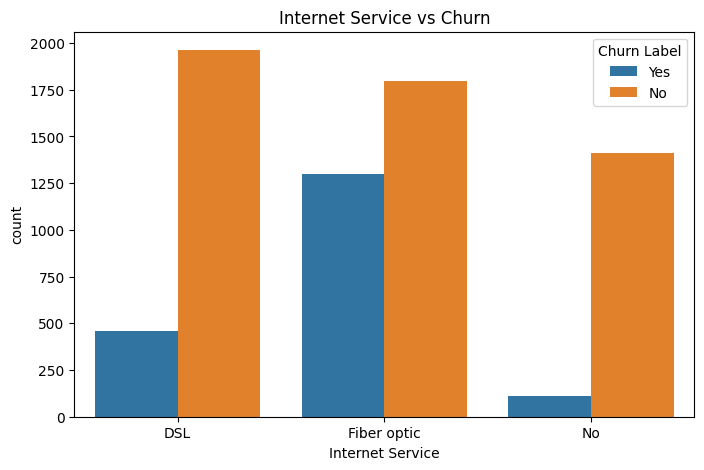

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Internet Service',
    hue='Churn Label',
    data=df_clean
)

plt.title('Internet Service vs Churn')
plt.show()

In [ ]:
pd.crosstab(df_clean['Payment Method'],
            df_clean['Churn Label'])

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


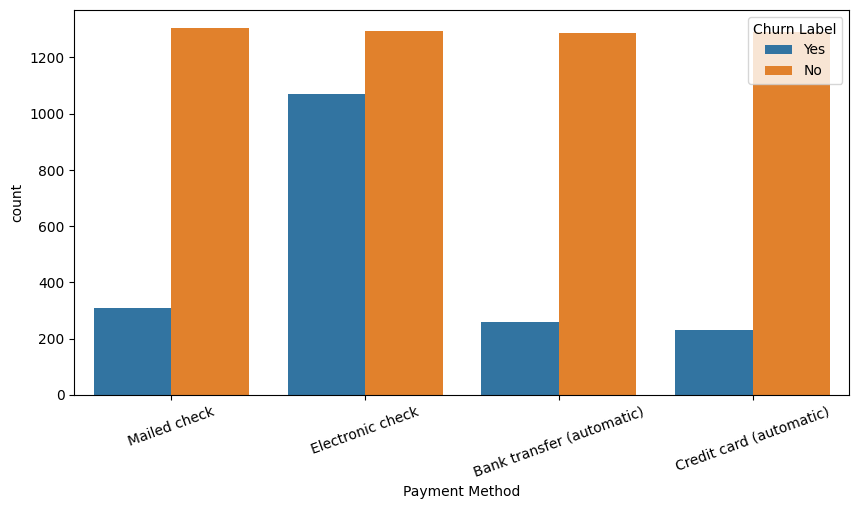

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Payment Method',
    hue='Churn Label',
    data=df_clean
)

plt.xticks(rotation=20)
plt.show()

In [ ]:
pd.crosstab(df_clean['Gender'],
            df_clean['Churn Label'])

Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


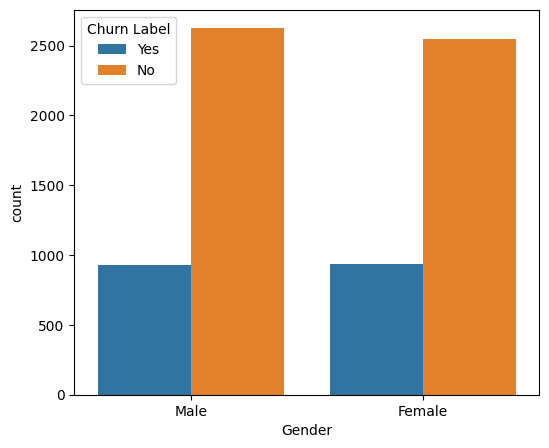

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    hue='Churn Label',
    data=df_clean
)

plt.show()

In [ ]:
df_clean[['Tenure Months',
          'Monthly Charges',
          'Total Charges']].describe()

,Tenure Months,Monthly Charges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [ ]:
df_clean['Total Charges'].dtype

dtype('O')

In [ ]:
df_clean['Total Charges'] = pd.to_numeric(
    df_clean['Total Charges'],
    errors='coerce'
)

df_clean.dropna(inplace=True)

df_clean['Total Charges'].describe()

,Total Charges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


                 Tenure Months  Monthly Charges  Total Charges
Tenure Months         1.000000         0.246862       0.825880
Monthly Charges       0.246862         1.000000       0.651065
Total Charges         0.825880         0.651065       1.000000


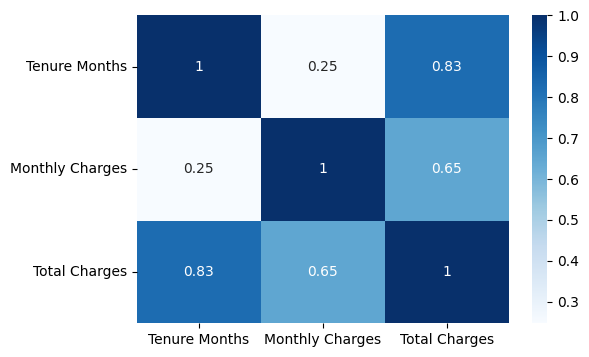

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges'
]

corr_matrix = df_clean[numeric_cols].corr()

print(corr_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues'
)
plt.show()

In [ ]:
df_clean['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
from scipy.stats import ttest_ind

churn_yes = df_clean[df_clean['Churn Label']=='Yes']['Tenure Months']
churn_no = df_clean[df_clean['Churn Label']=='No']['Tenure Months']

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -31.741289063447653
P-Value: 9.437650217574845e-207


In [ ]:
from scipy.stats import ttest_ind

churn_yes = df_clean[df_clean['Churn Label']=='Yes']['Monthly Charges']
churn_no = df_clean[df_clean['Churn Label']=='No']['Monthly Charges']

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 16.47959313114872
P-Value: 6.760843117980302e-60


In [ ]:
from scipy.stats import chi2_contingency

contract_table = pd.crosstab(
    df_clean['Contract'],
    df_clean['Churn Label']
)

chi2, p, dof, expected = chi2_contingency(contract_table)

print("Chi-Square:", chi2)
print("P-Value:", p)

Chi-Square: 1179.5458287339445
P-Value: 7.326182186265472e-257


In [ ]:
internet_table = pd.crosstab(
    df_clean['Internet Service'],
    df_clean['Churn Label']
)

chi2, p, dof, expected = chi2_contingency(internet_table)

print("Chi-Square:", chi2)
print("P-Value:", p)

Chi-Square: 728.6956143058694
P-Value: 5.831198962237274e-159


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df_clean.copy()

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1


In [ ]:
X = df_ml.drop('Churn Label', axis=1)
y = df_ml['Churn Label']

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.8081023454157783
Precision: 0.6468926553672316
Recall: 0.6122994652406417
F1: 0.6291208791208791
ROC AUC: 0.7456463444305822


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lr = LogisticRegression(
    max_iter=5000
)

In [ ]:
print(lr)

LogisticRegression(max_iter=5000)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_pred_dt))

Accuracy: 0.7249466950959488
Precision: 0.4831168831168831
Recall: 0.49732620320855614
F1: 0.4901185770750988
ROC AUC: 0.6523417076062142


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.7917555081734187
Precision: 0.6354515050167224
Recall: 0.5080213903743316
F1: 0.5646359583952452
ROC AUC: 0.7012517406857137


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

            Feature  Importance
18    Total Charges    0.177742
17  Monthly Charges    0.171203
4     Tenure Months    0.155509
14         Contract    0.082917
16   Payment Method    0.048670
8   Online Security    0.048343
11     Tech Support    0.044023
3        Dependents    0.038591
0            Gender    0.027905
9     Online Backup    0.027725


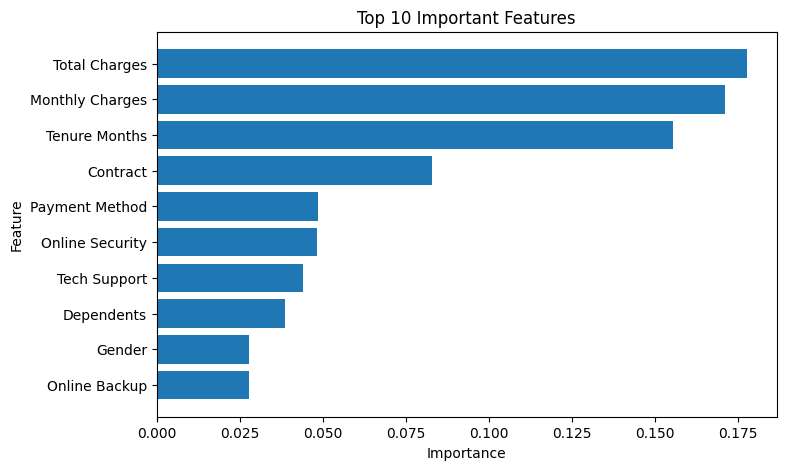

In [ ]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

[[908 125]
 [145 229]]


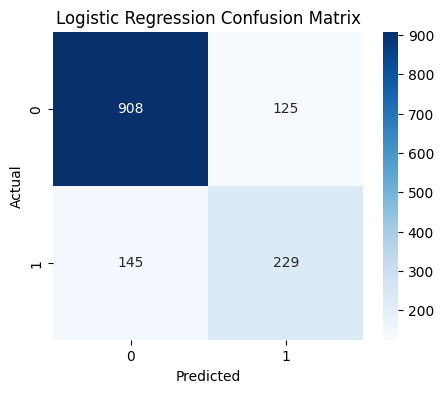

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()